In [16]:
using GLPK, JuMP, Plots
using Measures

## Costs to turn GAS BOILER on/off
Assumption:
- we have costs when the gas boiler is **turned on/off**
- if the boiler is on, it needs to run at a **minimum of 30 MW**

Conclusion:
- in one intervall, the gasboiler is not turned off for a longer time then normal - but is on the minimum level of **30 MW**

In [17]:
#DATA
N = 24      # amount timesteps   
M = 3       # amount heatsources

# 1 biomass boiler
# 2 gas boiler
# 3 heat pump

c = [185, 600, 260]            # Cost           - DKK / MWh
m = [150, 150, 150]         # Capacity          - MW
ramp_up = [30,100,60]       # Heat-up-speed     - MW / time step
ramp_down = [10,100,60];    # Cool-down-speed   - MW / time step


# DEMAND
# d = rand(0:450, N)
d = [370, 200, 230, 270, 450, 280, 240, 210, 370, 190, 180, 200, 0, 270, 300, 280, 240, 210, 260, 190,0,450,0,100];   # MW 

In [18]:
# GAS DATA
gas_min = 30            # if on, that at least at level 'gas_min'
gas_start_cost = 50000
gas_stop_cost = 1000;

In [19]:
model1 = Model(GLPK.Optimizer)

@variable(model1, x1[1:M,1:N] >= 0)

# GAS variables
@variable(model1, gas_on[1:N], Bin)
@variable(model1, gas_start[1:N], Bin)
@variable(model1, gas_stop[1:N], Bin)

# OBJECTIVE: minimize COST
@objective(model1, Min,
    sum(sum(x1[j,t] * c[j] for t=1:N) for j=1:M)    # general cost
    + gas_start_cost * sum(gas_start[t] for t=1:N)  # start cost - GAS
    + gas_stop_cost  * sum(gas_stop[t] for t=1:N))   # shutdown cost - GAS )

# CONSTRAINTS
# capacity
@constraint(model1, [j=1:M,i=1:N], x1[j,i] <= m[j])
# meet Demand
@constraint(model1, [i=1:N],   sum( x1[j,i] for j=1:M) >= d[i]    )
# ramp_up/down
@constraint(model1, [j=1:M, i=2:N],  x1[j,i] - x1[j,i-1] <= ramp_up[j])
@constraint(model1, [j=1:M, i=2:N],  x1[j,i-1] - x1[j,i] <= ramp_down[j])

# GAS
# capacity
@constraint(model1, [t=1:N], x1[2,t] <= m[2] * gas_on[t])
# Minimum gas output
@constraint(model1, [t=1:N], x1[2,t] >= gas_min * gas_on[t])
# start / shutdown
@constraint(model1, [t=2:N], gas_start[t] >= gas_on[t] - gas_on[t-1])
@constraint(model1, [t=2:N], gas_stop[t] >= gas_on[t-1] - gas_on[t])

optimize!(model1)

println("Solver status: ", termination_status(model1))
println("Solution status: ", primal_status(model1))
## Printing the solution
println("Objective value = ", objective_value(model1)) 

cost1 = 0
for j=1:M
    for i=1:N
        print(round(value(x1[j,i]),digits=2),"\t")
        cost1 += value(x1[j,i])*c[j]
    end
    println()
end
cost_Euro = round(cost1/7.5,digits=2)
println("Cost: ",cost1/1000000, " Million DKK \t (",cost_Euro, " in €)")

Solver status: OPTIMAL
Solution status: FEASIBLE_POINT
Objective value = 1.7185e6
150.0	140.0	140.0	130.0	150.0	140.0	130.0	120.0	150.0	140.0	140.0	130.0	120.0	150.0	150.0	150.0	150.0	150.0	140.0	130.0	120.0	150.0	140.0	130.0	
70.0	30.0	30.0	50.0	150.0	50.0	30.0	30.0	100.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	50.0	150.0	50.0	0.0	
150.0	90.0	60.0	90.0	150.0	90.0	80.0	60.0	120.0	60.0	40.0	70.0	60.0	120.0	150.0	130.0	90.0	60.0	120.0	60.0	90.0	150.0	90.0	30.0	
Cost: 1.6665 Million DKK 	 (222200.0 in €)


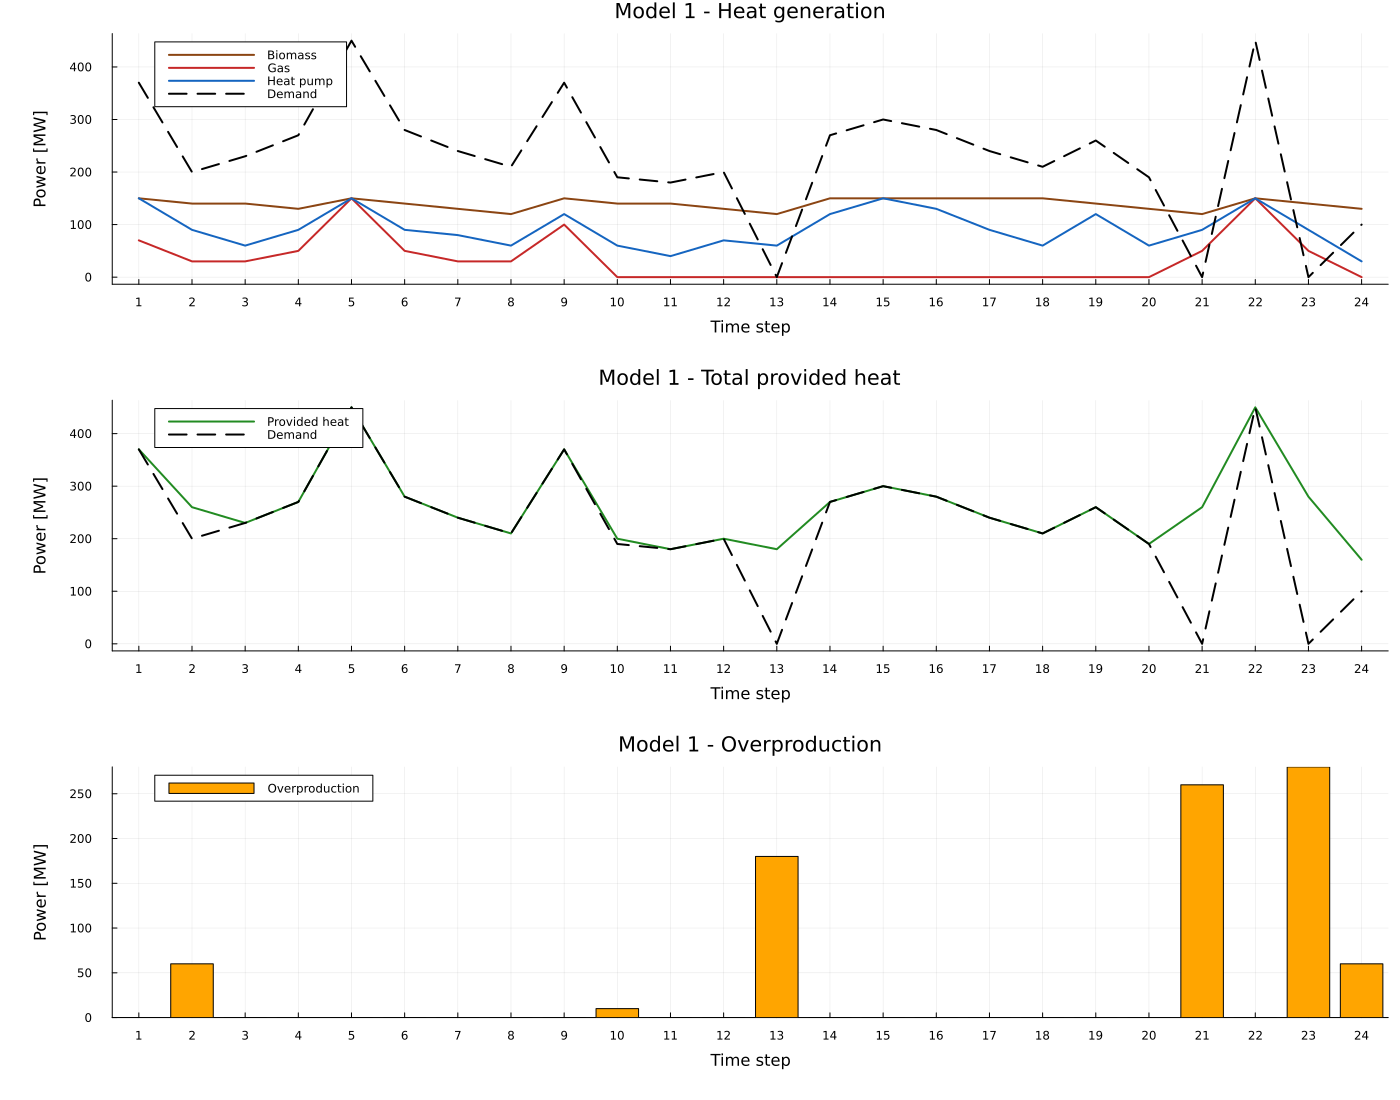

In [20]:
# plot MODEL1
xmin = 0.5
xmax = N + 0.5

x1_result = value.(x1)

biomass1  = x1_result[1,:]
gas1      = x1_result[2,:]
heatpump1 = x1_result[3,:]

total1 = biomass1 .+ gas1 .+ heatpump1
overproduction1 = max.(total1 .- d, 0)

# 1. HEAT SOURCES
p1_sources = plot(
    1:N,
    biomass1,
    label="Biomass",
    color="#8B4513",
    lw=2,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Model 1 - Heat generation",
    xticks=1:N,
    grid=true,
    xlims=(xmin,xmax))
plot!(p1_sources, 1:N, gas1,
    label="Gas",
    color="#C62828",
    lw=2)
plot!(p1_sources, 1:N, heatpump1,
    label="Heat pump",
    color="#1565C0",
    lw=2)
plot!(p1_sources, 1:N, d,
    label="Demand",
    color=:black,
    lw=2,
    linestyle=:dash)

# 2. TOTAL HEAT
p1_total = plot(
    1:N,
    total1,
    label="Provided heat",
    color="#228B22",
    lw=2,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Model 1 - Total provided heat",
    xticks=1:N,
    grid=true,
    xlims=(xmin,xmax),
    legend=:topleft)
plot!(p1_total, 1:N, d,
    label="Demand",
    color=:black,
    lw=2,
    linestyle=:dash)

# 3. OVERPRODUCTION
p1_overproduction = bar(
    1:N,
    overproduction1,
    label="Overproduction",
    color=:orange,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Model 1 - Overproduction",
    xticks=1:N,
    grid=true,
    xlims=(xmin,xmax),
    legend=:topleft)

hline!(
    p1_overproduction,
    [0],
    color=:black,
    lw=1,
    label="")
# COMBINE
plot_model1 = plot(
    p1_sources,
    p1_total,
    p1_overproduction,
    layout=@layout([
        a
        b
        c
    ]),
    link=:x,
    left_margin=12mm,
    bottom_margin=8mm,
    size=(1400,1100))

display(plot_model1)

In [21]:
# 2opt
#THERMAL STORAGE
E_maxCharge = 75        # MW
E_maxDischarge = 75     # MW   
E_max = 150             # Storage Capacity  - MWh
E_start = 75           # Start Capacity    - MWh   

eff_charge = 0.95        # Heat loss while charging        
eff_discharge = 0.95     # Heat loss while discharging
eff_storage = 1.        # Heat loss while storing       - no influence!


using GLPK, JuMP, Plots
model2 = Model(GLPK.Optimizer)

@variable(model2, x2[1:3,1:N] >= 0)

@variable(model2, E[1:N] >= 0)
@variable(model2, charge[1:N] >= 0)
@variable(model2, discharge[1:N] >= 0)
@variable(model2, excessHeat[1:N] >= 0)

@variable(model2, gas_on[1:N], Bin)
@variable(model2, gas_start[1:N], Bin)
@variable(model2, gas_stop[1:N], Bin)

# KOSTEN minimieren
@objective(model2, Min,
    sum(sum(x2[j,t] * c[j] for t=1:N) for j=1:M)
    + gas_start_cost * sum(gas_start[t] for t=1:N)
    + gas_stop_cost  * sum(gas_stop[t] for t=1:N))
# CONSTRAINTS:
# kann maximalen Wirkungsgrad nicht übersteigen    -    je Heizquelle
@constraint(model2, [j=1:M,t=1:N], x2[j,t] <= m[j])
# DEMAND hast to be met     -    für alle Zeitpunkte i
# @constraint(model, [t=1:N],   sum( x2[j,t] for j=1:M) >= d[t]    )

# heating speed
@constraint(model2, [j=1:M, t=2:N],  x2[j,t] - x2[j,t-1] <= ramp_up[j])
@constraint(model2, [j=1:M, t=2:N],  x2[j,t-1] - x2[j,t] <= ramp_down[j])

# SPEICHER
@constraint(model2, [t=1:N], charge[t]    <= E_maxCharge)                                 # charging-speed
@constraint(model2, [t=1:N], discharge[t] <= E_maxDischarge)
@constraint(model2, [t=1:N], E[t]         <= E_max)                                       # storage-capazity
@constraint(model2, [t=1:N], sum( x2[i,t] for i=1:M) + discharge[t] == d[t] + charge[t] + excessHeat[t])      # heat-equality

@constraint(model2, [t=2:N], E[t] == eff_storage * E[t-1] + eff_charge * charge[t] - 1/eff_discharge * discharge[t])          # keep track of storage
@constraint(model2, E[1] == E_start + eff_charge * charge[1] - 1/eff_discharge * discharge[1])
@constraint(model2, E[N] == E_start)

# Gas capacity
@constraint(model2, [t=1:N], x2[2,t] <= m[2] * gas_on[t])
# Minimum gas output
@constraint(model2, [t=1:N], x2[2,t] >= gas_min * gas_on[t])
# startup / shutdown
@constraint(model2, [t=2:N], gas_start[t] >= gas_on[t] - gas_on[t-1])
@constraint(model2, [t=2:N], gas_stop[t] >= gas_on[t-1] - gas_on[t])

optimize!(model2)

println("Solver status: ", termination_status(model2))
println("Solution status: ", primal_status(model2))
## Printing the solution
println("Objective value = ", objective_value(model2)) 

cost2 = 0
for j=1:M
    for i=1:N
        print(round(value(x1[j,i]),digits=2),"\t")
        cost2 += value(x1[j,i])*c[j]
    end
    println()
end
cost2_Euro = round(cost2/7.5,digits=2)
println("\nCost: ",cost2/1000000, " Million DKK \t (",cost2_Euro, " in €)\n")

println("Excess Heat:\n",round.(value.(excessHeat),digits=2))

Solver status: OPTIMAL
Solution status: FEASIBLE_POINT
Objective value = 1.413390083102493e6
150.0	140.0	140.0	130.0	150.0	140.0	130.0	120.0	150.0	140.0	140.0	130.0	120.0	150.0	150.0	150.0	150.0	150.0	140.0	130.0	120.0	150.0	140.0	130.0	
70.0	30.0	30.0	50.0	150.0	50.0	30.0	30.0	100.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	50.0	150.0	50.0	0.0	
150.0	90.0	60.0	90.0	150.0	90.0	80.0	60.0	120.0	60.0	40.0	70.0	60.0	120.0	150.0	130.0	90.0	60.0	120.0	60.0	90.0	150.0	90.0	30.0	

Cost: 1.6665 Million DKK 	 (222200.0 in €)

Excess Heat:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 45.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 110.0, 0.0, 161.05, 0.0]


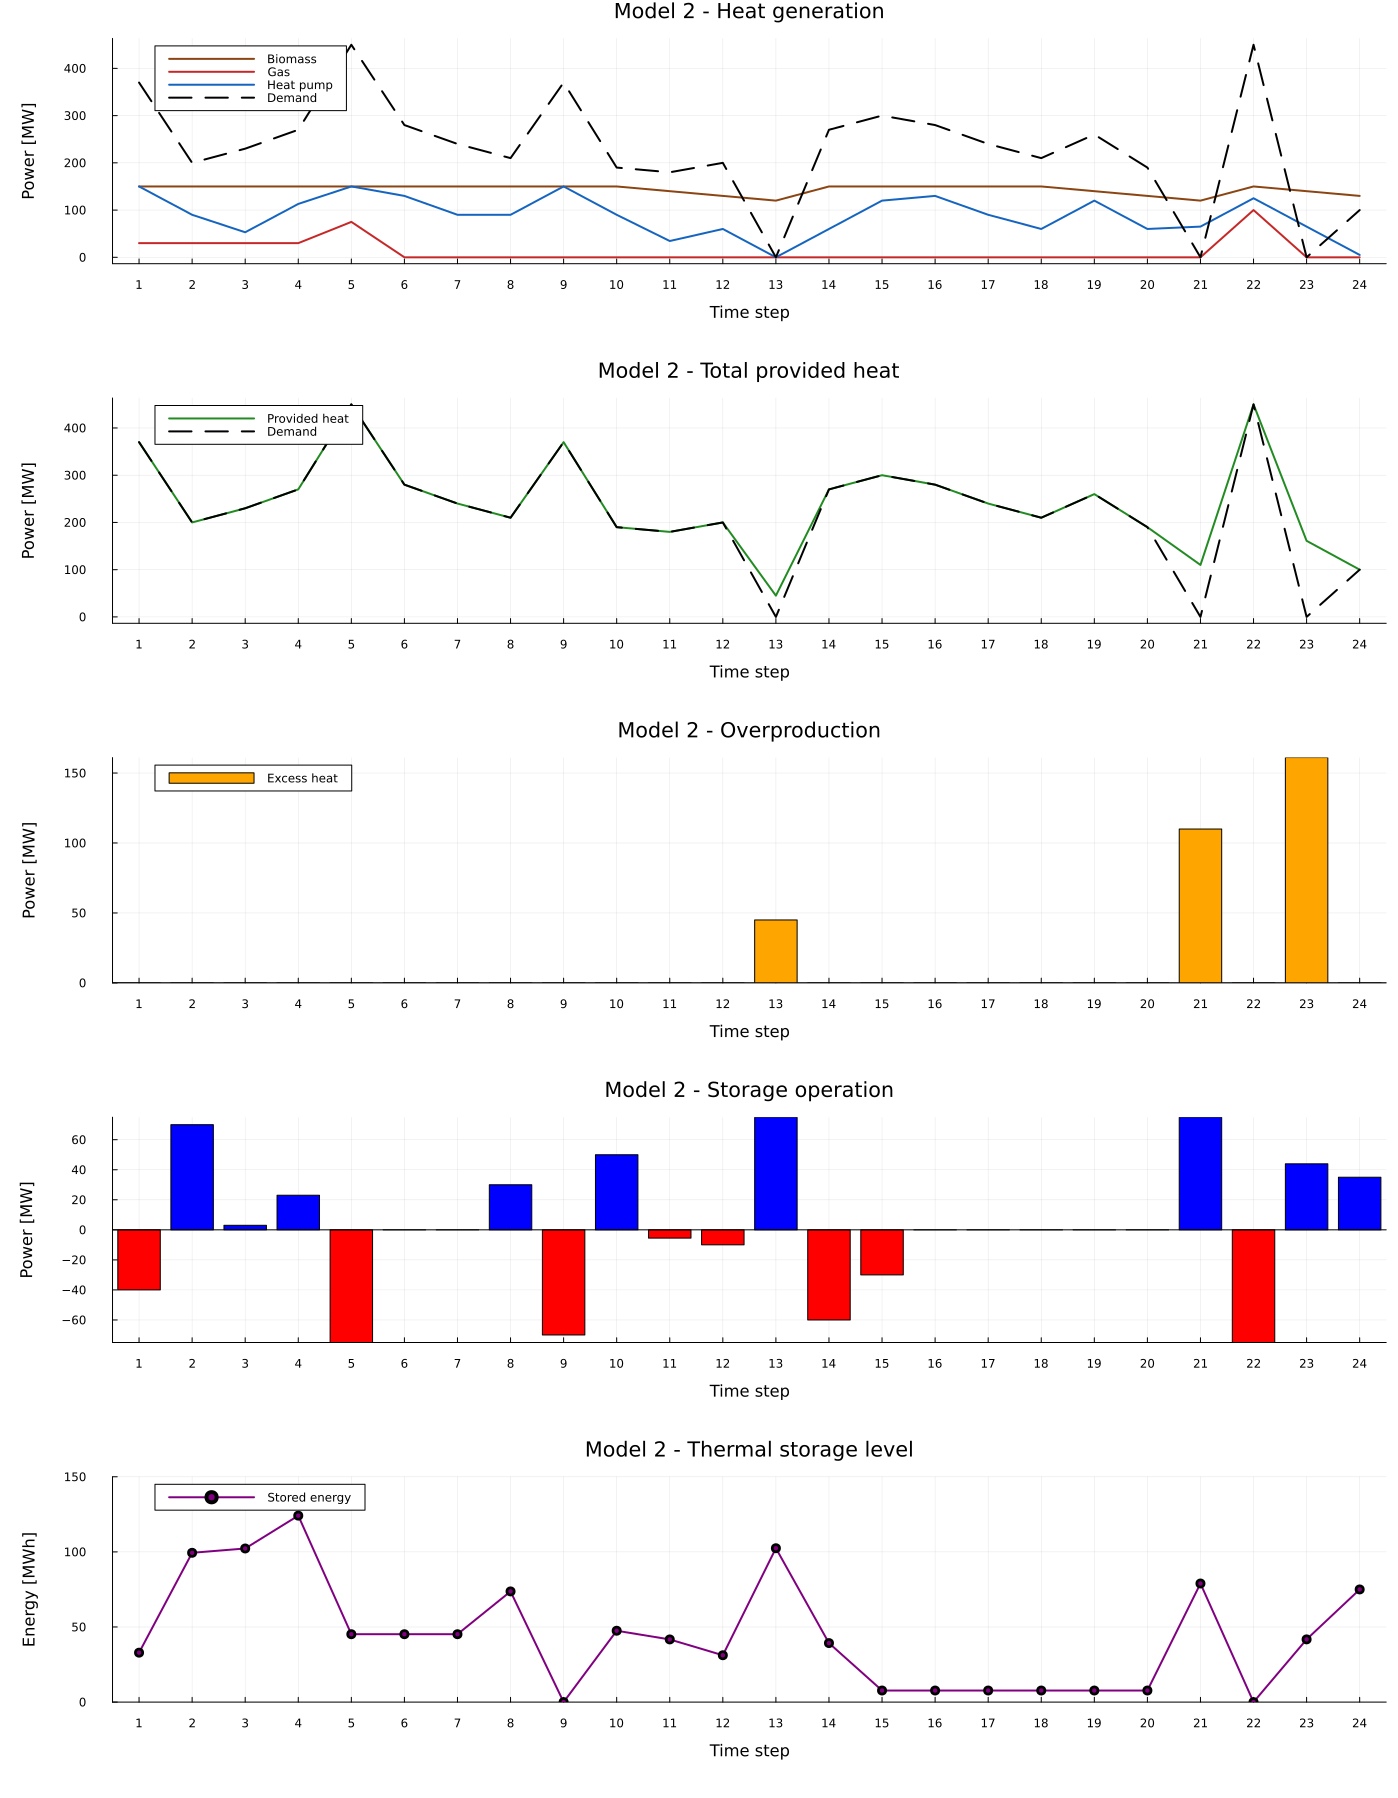

In [ ]:
# plot MODEL2
xmin = 0.5
xmax = N + 0.5

x2_result = value.(x2)

biomass2  = x2_result[1,:]
gas2      = x2_result[2,:]
heatpump2 = x2_result[3,:]

charge2    = value.(charge)
discharge2 = value.(discharge)
storage2   = value.(E)
excess2    = value.(excessHeat)

# positive = storage supplies heat
# negative = storage is charged
storage_movement2 = discharge2 .- charge2
total_generation2 = biomass2 .+ gas2 .+ heatpump2

# Heat actually available for demand
provided_heat2 = total_generation2 .+ storage_movement2

# 1. HEAT SOURCES
p2_sources = plot(
    1:N,
    biomass2,
    label="Biomass",
    color="#8B4513",
    lw=2,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Model 2 - Heat generation",
    xticks=1:N,
    grid=true,
    xlims=(xmin,xmax))
plot!(p2_sources, 1:N, gas2,
    label="Gas",
    color="#C62828",
    lw=2)
plot!(p2_sources, 1:N, heatpump2,
    label="Heat pump",
    color="#1565C0",
    lw=2)
plot!(p2_sources, 1:N, d,
    label="Demand",
    color=:black,
    lw=2,
    linestyle=:dash)

# 2. TOTAL PROVIDED HEAT
p2_total = plot(
    1:N,
    provided_heat2,
    label="Provided heat",
    color="#228B22",
    lw=2,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Model 2 - Total provided heat",
    xticks=1:N,
    grid=true,
    xlims=(xmin,xmax),
    legend=:topleft)
plot!(p2_total, 1:N, d,
    label="Demand",
    color=:black,
    lw=2,
    linestyle=:dash)

# 3. EXCESS HEAT
p2_excess = bar(
    1:N,
    excess2,
    label="Excess heat",
    color=:orange,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Model 2 - Overproduction",
    xticks=1:N,
    grid=true,
    xlims=(xmin,xmax),
    legend=:topleft)
hline!(
    p2_excess,
    [0],
    color=:black,
    lw=1,
    label="")

# 4. STORAGE OPERATION
# positive bar = charging
# negative bar = discharging
storage_plot = charge2 .- discharge2
storage_colors = [
    storage_plot[t] >= 0 ? :blue : :red
    for t in 1:N]

p2_movement = bar(
    1:N,
    storage_plot,
    label="",
    color=storage_colors,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Model 2 - Storage operation",
    xticks=1:N,
    grid=true,
    xlims=(xmin,xmax))
hline!(
    p2_movement,
    [0],
    color=:black,
    lw=1,
    label="")

# 5. STORAGE LEVEL
p2_storage = plot(
    1:N,
    storage2,
    label="Stored energy",
    color=:purple,
    lw=2,
    marker=:circle,
    xlabel="Time step",
    ylabel="Energy [MWh]",
    title="Model 2 - Thermal storage level",
    xticks=1:N,
    grid=true,
    ylims=(0,E_max),
    xlims=(xmin,xmax),
    legend=:topleft)

# COMBINE
plot_model2 = plot(
    p2_sources,
    p2_total,
    p2_excess,
    p2_movement,
    p2_storage,
    layout=@layout([
        a
        b
        c
        d
        e
    ]),
    link=:x,
    left_margin=12mm,
    bottom_margin=8mm,
    size=(1400,1800))

display(plot_model2)